In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/notebooks/aryannahata07/research-paper-topic-discovery/tfidf_feature_names.pkl
/kaggle/input/notebooks/aryannahata07/research-paper-topic-discovery/tfidf_vocab.json
/kaggle/input/notebooks/aryannahata07/research-paper-topic-discovery/__results__.html
/kaggle/input/notebooks/aryannahata07/research-paper-topic-discovery/__notebook__.ipynb
/kaggle/input/notebooks/aryannahata07/research-paper-topic-discovery/tfidf_features.npz
/kaggle/input/notebooks/aryannahata07/research-paper-topic-discovery/__output__.json
/kaggle/input/notebooks/aryannahata07/research-paper-topic-discovery/custom.css
/kaggle/input/notebooks/aryannahata07/research-paper-topic-discovery/__results___files/__results___8_0.png
/kaggle/input/notebooks/aryannahata07/research-paper-topic-discovery/.virtual_documents/__notebook_source__.ipynb
/kaggle/input/notebooks/tanishksinghthakur/uslproj/arxiv_with_topics.csv
/kaggle/input/notebooks/tanishksinghthakur/uslproj/__results__.html
/kaggle/input/notebooks/tanishks

In [2]:
import numpy as np
import pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")


Libraries loaded!


In [3]:
input_path = "/kaggle/input/notebooks/tanishksinghthakur/uslproj/"

# Load document-topic matrix (papers x 20 topics)
W = sparse.load_npz(input_path + "document_topic_matrix.npz").toarray()

# Load the dataframe
df = pd.read_csv(input_path + "arxiv_with_topics.csv", low_memory=False)

print(f"Document-Topic Matrix Shape: {W.shape}")
print(f"DataFrame Shape: {df.shape}")
print(f"\nTopic Distribution:")
print(df['dominant_topic'].value_counts().sort_index())


Document-Topic Matrix Shape: (2968855, 20)
DataFrame Shape: (2968855, 5)

Topic Distribution:
dominant_topic
0     915638
1     420251
2     325563
3     138888
4      78422
5      88603
6     105933
7     122897
8      68466
9      89425
10     65462
11     70716
12     98174
13     35037
14     52127
15     51662
16     43122
17     51456
18     67031
19     79982
Name: count, dtype: int64


In [4]:
SAMPLE_SIZE = 50000

# Sample proportionally from each topic so all 20 are represented
sampled_indices = []

for topic_id in range(20):
    topic_indices = np.where(df['dominant_topic'] == topic_id)[0]
    topic_proportion = len(topic_indices) / len(df)
    n_samples = max(100, int(SAMPLE_SIZE * topic_proportion))  # at least 100 per topic
    sampled = np.random.choice(topic_indices, size=min(n_samples, len(topic_indices)), replace=False)
    sampled_indices.extend(sampled)

sampled_indices = np.array(sampled_indices)
W_sample = W[sampled_indices]
df_sample = df.iloc[sampled_indices].reset_index(drop=True)

print(f"Total sampled: {len(sampled_indices)} papers")
print(df_sample['dominant_topic'].value_counts().sort_index())


Total sampled: 49991 papers
dominant_topic
0     15420
1      7077
2      5482
3      2339
4      1320
5      1492
6      1784
7      2069
8      1153
9      1506
10     1102
11     1190
12     1653
13      590
14      877
15      870
16      726
17      866
18     1128
19     1347
Name: count, dtype: int64


In [5]:
!pip install umap-learn -q

import umap

print("Running UMAP on 50k papers (takes 3-8 minutes)...")

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    random_state=42,
    verbose=True
)

umap_results = reducer.fit_transform(W_sample)

df_sample['umap_x'] = umap_results[:, 0]
df_sample['umap_y'] = umap_results[:, 1]

print("UMAP complete!")


2026-03-17 13:52:57.136270: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773755577.408015      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773755577.477997      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773755578.108581      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773755578.108624      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773755578.108627      17 computation_placer.cc:177] computation placer alr

Running UMAP on 50k papers (takes 3-8 minutes)...
UMAP(n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Tue Mar 17 13:53:30 2026 Construct fuzzy simplicial set
Tue Mar 17 13:53:30 2026 Finding Nearest Neighbors
Tue Mar 17 13:53:30 2026 Building RP forest with 16 trees
Tue Mar 17 13:53:35 2026 NN descent for 16 iterations
	 1  /  16
	 2  /  16
	Stopping threshold met -- exiting after 2 iterations
Tue Mar 17 13:53:58 2026 Finished Nearest Neighbor Search
Tue Mar 17 13:54:01 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Tue Mar 17 13:55:01 2026 Finished embedding
UMAP complete!


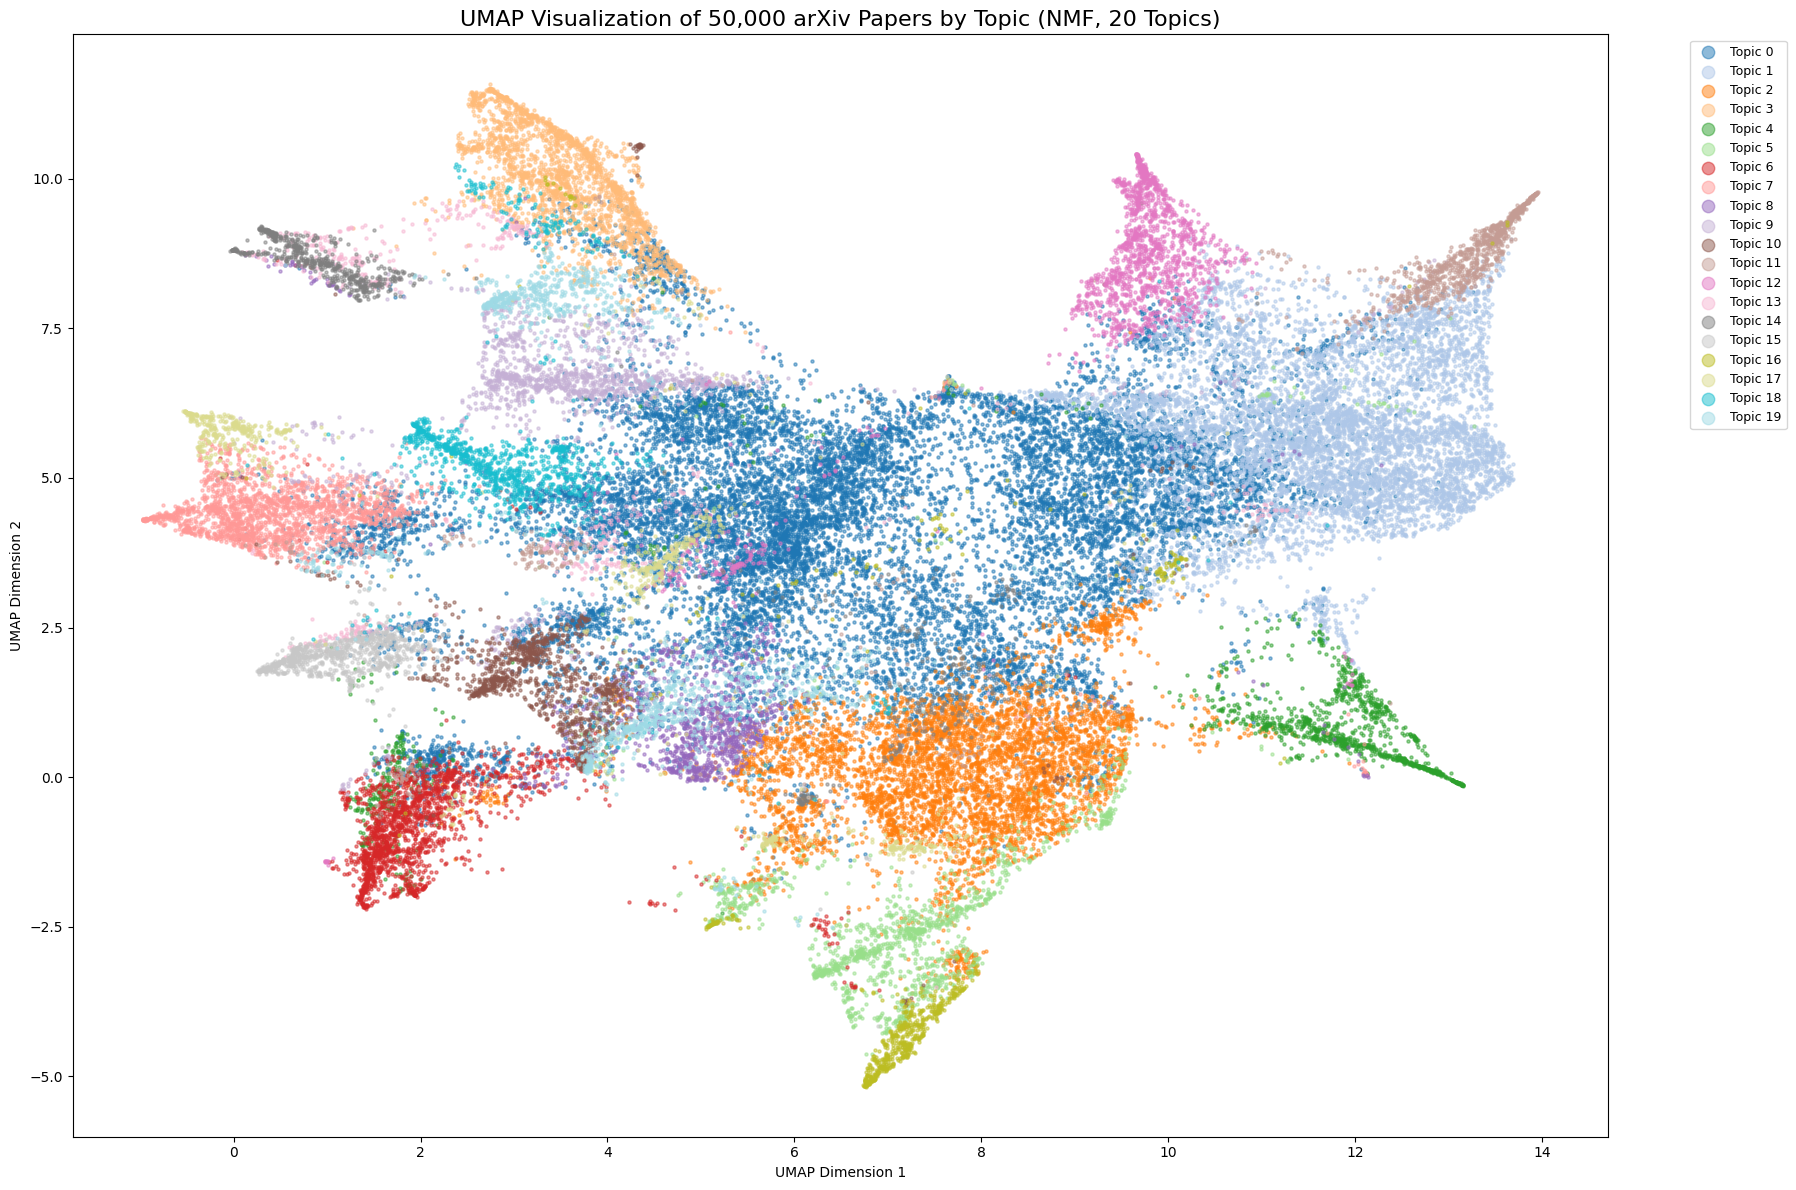

Saved: umap_plot.png


In [6]:
num_topics = 20
colors = cm.get_cmap('tab20', num_topics)

plt.figure(figsize=(18, 12))

for topic_id in range(num_topics):
    mask = df_sample['dominant_topic'] == topic_id
    plt.scatter(
        df_sample.loc[mask, 'umap_x'],
        df_sample.loc[mask, 'umap_y'],
        c=[colors(topic_id)],
        label=f'Topic {topic_id}',
        alpha=0.5,
        s=5
    )

plt.title('UMAP Visualization of 50,000 arXiv Papers by Topic (NMF, 20 Topics)', fontsize=16)
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=4, fontsize=9)
plt.tight_layout()
plt.savefig('/kaggle/working/umap_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: umap_plot.png")


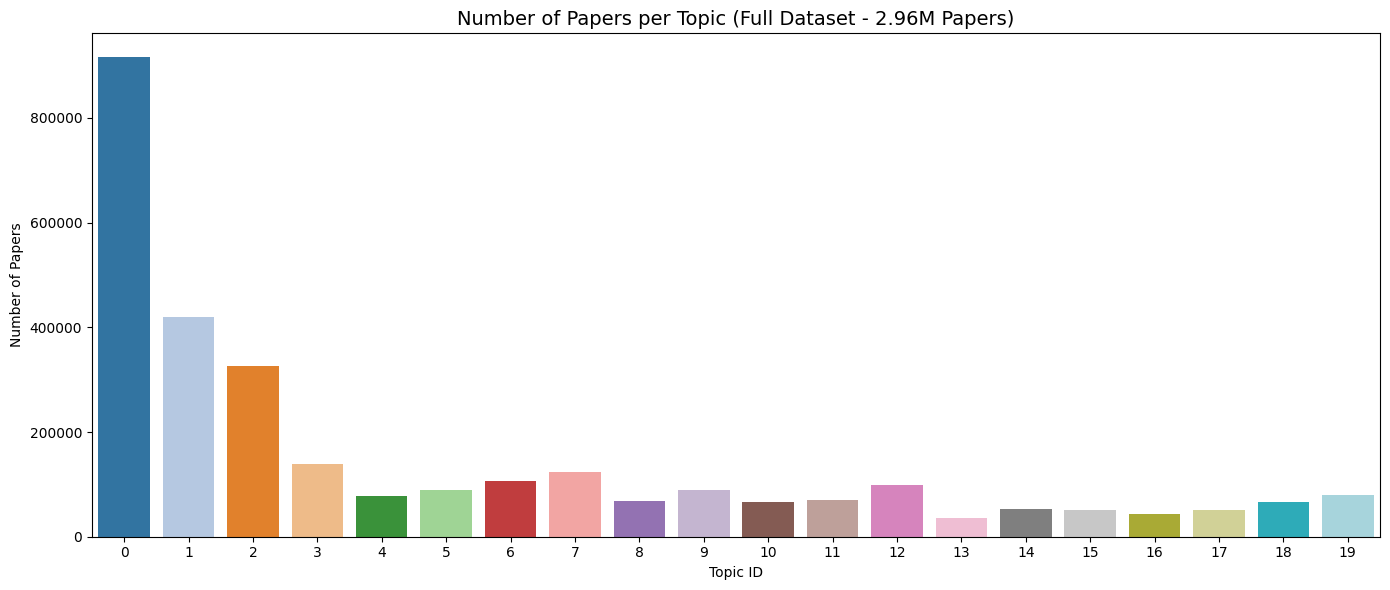

Saved: topic_distribution.png


In [7]:
plt.figure(figsize=(14, 6))
topic_counts = df['dominant_topic'].value_counts().sort_index()
sns.barplot(x=topic_counts.index, y=topic_counts.values, palette='tab20', hue=topic_counts.index, legend=False)
plt.title('Number of Papers per Topic (Full Dataset - 2.96M Papers)', fontsize=14)
plt.xlabel('Topic ID')
plt.ylabel('Number of Papers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/kaggle/working/topic_distribution.png', dpi=150)
plt.show()
print("Saved: topic_distribution.png")


In [8]:
import pickle
from sklearn.decomposition import MiniBatchNMF

nb2_path = "/kaggle/input/notebooks/aryannahata07/research-paper-topic-discovery/"

print("Loading TF-IDF matrix...")
tfidf_matrix = sparse.load_npz(nb2_path + "tfidf_features.npz")

print("Loading feature names...")
with open(nb2_path + "tfidf_feature_names.pkl", "rb") as f:
    feature_names = pickle.load(f)

print(f"TF-IDF Shape: {tfidf_matrix.shape}")
print(f"Vocabulary size: {len(feature_names)}")

print("\nRetraining NMF (needed for pyLDAvis)...")
nmf_model = MiniBatchNMF(n_components=20, random_state=42, batch_size=1024, max_iter=200)
nmf_model.fit(tfidf_matrix)
print("NMF ready!")


Loading TF-IDF matrix...
Loading feature names...
TF-IDF Shape: (2968855, 10000)
Vocabulary size: 10000

Retraining NMF (needed for pyLDAvis)...
NMF ready!


In [9]:
import pyLDAvis
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore')

print("Preparing pyLDAvis data manually...")

H = nmf_model.components_
topic_term_dists = H / H.sum(axis=1, keepdims=True)

print("Transforming full dataset...")
W_full = nmf_model.transform(tfidf_matrix)

row_sums = W_full.sum(axis=1)
valid_mask = row_sums > 0
W_valid = W_full[valid_mask]
print(f"Removed {(~valid_mask).sum()} zero rows, using {valid_mask.sum()} documents")

doc_topic_dists = normalize(W_valid, norm='l1')
doc_lengths = np.array(tfidf_matrix[valid_mask].sum(axis=1)).flatten().astype(int)
doc_lengths[doc_lengths == 0] = 1
term_frequency = np.array(tfidf_matrix.sum(axis=0)).flatten()

print("Building visualization...")
vis_data = pyLDAvis.prepare(
    topic_term_dists=topic_term_dists,
    doc_topic_dists=doc_topic_dists,
    doc_lengths=doc_lengths,
    vocab=list(feature_names),
    term_frequency=term_frequency,
    mds='tsne',
    sort_topics=False
)

pyLDAvis.save_html(vis_data, '/kaggle/working/lda_vis.html')
print("Saved: lda_vis.html")
pyLDAvis.display(vis_data)


Preparing pyLDAvis data manually...
Transforming full dataset...
Removed 10 zero rows, using 2968845 documents
Building visualization...
Saved: lda_vis.html
